---
tags: [algorithm, oracle-based]
---

# Grover探索入門

Grover探索は、確率振幅を増幅することで、構造を持たない探索空間からマークされた要素を見つけるアルゴリズムです{cite:p}`10.1145/237814.237866`。サイズ$N$の探索空間にマークされた要素が1つある場合、古典的な全探索では$O(N)$回の問い合わせが必要ですが、Grover探索では$O(\sqrt{N})$回のオラクル問い合わせで探索でき、古典計算に対して2次的な計算速度の加速を示すことが知られています。

このノートブックでは、Qamomileの組み込みヘルパー`grover_search`を使用し、Grover探索をQamomileで実装する方法を紹介します。4量子ビットの検索レジスタからマークされた状態$|0101\rangle$を探索し、位相オラクル内で補助量子ビットを1つ使う5量子ビット回路を構成します。最後に、振幅増幅の前後における検索レジスタの状態確率をヒストグラムで比較します。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
# 数値計算、プロット、シミュレータ、Qamomileのユーティリティを読み込みます。
import math
import os

import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## アルゴリズム

$x_\star\in\{0,1\}^n$を、1つだけマークされた$n$量子ビットの対象状態とします。探索空間の大きさを$N=2^n$とし、$f(x)$は$x=x_\star$の場合にのみ1、それ以外では0になる関数とします。対応する位相オラクルは、この条件を相対位相として表します。

$$
O_f|x\rangle = (-1)^{f(x)}|x\rangle.
$$

したがって、オラクルは$|x_\star\rangle$を$-|x_\star\rangle$へ変化させ、ほかの基底状態は変化させません。位相だけでは測定確率は変化しません。Grover探索では位相オラクルと一様重ね合わせに関する反転を組み合わせ、対象状態の確率振幅を増幅します。

:::{note}
**オラクルとは？**

量子アルゴリズムにおけるオラクルとは、入力が条件を満たすかを判定する処理を、可逆な量子演算として表したものです。アルゴリズムからは内部実装に依存せず使えるため、ブラックボックスとして扱われます。これは実装が不要という意味ではなく、実際のオラクル回路は探索問題ごとに構成します。Grover探索では位相オラクルを使い、判定結果を別の量子ビットへ出力する代わりに、条件を満たす状態の符号を反転します。オラクルを1回適用することを、1回のオラクル問い合わせと数えます。
:::

### ステップ1：一様重ね合わせ状態を準備する

$n$量子ビットの状態$|0\rangle^{\otimes n}$から始め、アダマールゲートによって

$$
|s\rangle = H^{\otimes n}|0\rangle^{\otimes n}
= \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}|x\rangle,
\qquad N=2^n
$$

を準備します。対象状態が1つの場合、$|\mathrm{good}\rangle=|x_\star\rangle$とし、残りの$N-1$個の基底状態の正規化された重ね合わせを$|\mathrm{bad}\rangle$と定義します。

$$
|\mathrm{bad}\rangle
= \frac{1}{\sqrt{N-1}}
\sum_{x\ne x_\star}|x\rangle.
$$

初期状態は次のように表せます。

$$
|s\rangle
= \cos\theta|\mathrm{bad}\rangle
+ \sin\theta|\mathrm{good}\rangle,
\qquad
\theta=\arcsin\frac{1}{\sqrt{N}}.
$$

### ステップ2：位相オラクルで対象状態をマークする

位相オラクルは、次の符号反転を適用します。

$$
O_f|x_\star\rangle=-|x_\star\rangle.
$$

オラクルはGrover探索の問題に依存する部分です。対象状態だけをマークする回路、またはより一般に探索条件を満たす状態をマークする回路を用意し、一時的に使った補助量子ビットはオラクルを終了する前に元の状態へ戻す必要があります。

### ステップ3：一様重ね合わせ状態に関して反転する

オラクルの後に拡散演算子

$$
D=2|s\rangle\langle s|-I
$$

を適用し、すべての確率振幅を平均値に関して反転します。したがって、1回のGrover反復は

$$
G=DO_f
$$

です。$|\mathrm{bad}\rangle$と$|\mathrm{good}\rangle$が張る2次元平面では、オラクルと拡散演算子による2つの反転を組み合わせることで、対象状態へ向かって$2\theta$だけ回転します。

### ステップ4：Grover反復を繰り返す

$r$回反復した後の検索レジスタの状態は

$$
G^r|s\rangle
= \cos((2r+1)\theta)|\mathrm{bad}\rangle
+ \sin((2r+1)\theta)|\mathrm{good}\rangle
$$

です。したがって、対象状態を測定する確率は

$$
P_r=\sin^2((2r+1)\theta)
$$

です。$P_r$が最初に最大になるのは、累積した角度$(2r+1)\theta$が最適な角度$\pi/2$に最も近づくときです。Qamomileの`grover_iteration_count(n, 1)`ヘルパーを使うと、検索量子ビット数から適切な整数の反復回数を自動的に計算できます。それ以上反復すると、対象状態から確率振幅が離れることがあります。

### ステップ5：検索レジスタを測定する

選んだ回数だけ反復した後に測定すると、高い確率で$x_\star$が得られます。組み込みの`qmc.grover_search`関数は一様重ね合わせを準備し、指定された回数だけオラクルと拡散演算子を反復します。呼び出し側は問題に依存する位相オラクルを渡し、返された検索レジスタを測定します。

まとめると、Grover探索は次の手順で実行します。

1. $n$個の検索量子ビットを確保し、$|0\rangle^{\otimes n}$へ初期化します。
2. アダマールゲートを適用し、$N=2^n$個の状態の一様重ね合わせを作ります。
3. $|x_\star\rangle$の位相を反転する位相オラクルを適用します。
4. 拡散演算子を適用し、対象状態の確率振幅を増幅します。
5. オラクルと拡散演算子を選んだ回数だけ繰り返します。
6. 検索レジスタを測定します。

## Qamomileでの実装：`grover_search`関数

### 問題設定

ここからは、一般のアルゴリズムを4量子ビットの検索レジスタへ適用します。そのため$N=2^4=16$であり、$|0101\rangle$だけをマークします。Grover探索を実行する前は、一様重ね合わせに含まれる各状態の確率が$1/16$です。マークされた状態が1つの場合、`grover_iteration_count(4, 1)`は反復回数3を返します。3回反復した後、マークされた状態を測定する理想的な確率は約$0.9613$です。

5番目の量子ビットはオラクルの補助量子ビットです。オラクルを適用する前後で$|0\rangle$となるため、Grover反復ごとに同じ物理量子ビットを再利用できます。

In [3]:
# 具体的な探索問題とサンプリング設定を定義します。
SEARCH_QUBITS = 4
NUM_MARKED = 1
MARKED_STATE = "0101"
ITERATIONS = qmc.grover_iteration_count(SEARCH_QUBITS, NUM_MARKED)

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
SHOTS = 512 if docs_test_mode else 4096
SAMPLER_SEED = 42

theta = math.asin(math.sqrt(NUM_MARKED / 2**SEARCH_QUBITS))
ideal_marked_probability = math.sin((2 * ITERATIONS + 1) * theta) ** 2

print("search qubits:", SEARCH_QUBITS)
print("marked state:", MARKED_STATE)
print("Grover iterations:", ITERATIONS)
print("ideal marked-state probability:", f"{ideal_marked_probability:.6f}")

assert ITERATIONS == 3
assert ideal_marked_probability > 0.96

search qubits: 4
marked state: 0101
Grover iterations: 3
ideal marked-state probability: 0.961319


### 位相オラクル

以下のオラクルでは、マルチCNOTゲートによる位相マーキングを使います。この例では、専用の補助量子ビットを対象として使います。Xゲートとアダマールゲートで$|-\rangle$を準備し、マルチCNOTゲートの位相キックバックによって`|0101>`をマークします。最後にアダマールゲートとXゲートを適用し、補助量子ビットを$|0\rangle$へ戻します。位相キックバック部分の前後にあるXゲートは、`0101`の0であるビットを1へ写した後、もとの基底ラベルへ戻します。

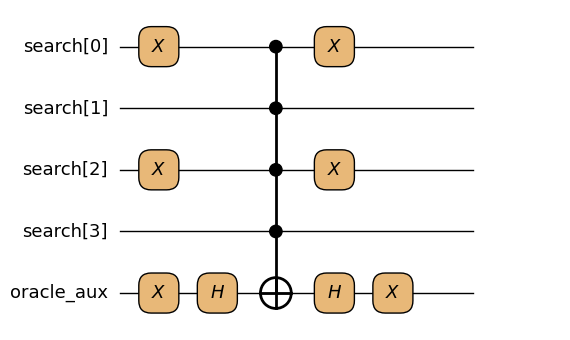

In [4]:
# |0101>をマークするオラクルを実装します。
@qmc.qkernel
def oracle_operator(
    search: qmc.Vector[qmc.Qubit],
) -> qmc.Vector[qmc.Qubit]:
    oracle_aux = qmc.qubit(name="oracle_aux")

    # |0101>を|1111>へ写し、すべて1の制御条件で検出できるようにします。
    search[0] = qmc.x(search[0])
    search[2] = qmc.x(search[2])

    # 補助量子ビットを|->へ準備します。
    oracle_aux = qmc.x(oracle_aux)
    oracle_aux = qmc.h(oracle_aux)

    # すべての検索量子ビットが1の場合にのみ補助量子ビットを反転します。
    multi_controlled_x = qmc.control(
        qmc.x,
        num_controls=search.shape[0],
    )
    search, oracle_aux = multi_controlled_x(search, oracle_aux)

    # 再利用できるように補助量子ビットを|0>へ戻します。
    oracle_aux = qmc.h(oracle_aux)
    oracle_aux = qmc.x(oracle_aux)

    # もとの計算基底ラベルへ戻します。
    search[0] = qmc.x(search[0])
    search[2] = qmc.x(search[2])
    return search


oracle_operator.draw(search=SEARCH_QUBITS, fold_loops=False)

### Grover探索の量子カーネル

`uniform_superposition`は、Grover探索を適用する前の初期状態を取得します。Grover探索用の回路と同じように4つの検索量子ビットと1つの補助量子ビットを確保しますが、一様重ね合わせを作って測定するのは検索レジスタだけです。

`grover_search_example`は、`oracle_operator`と反復回数を`qmc.grover_search`へ渡します。`iterations`は回路構造を決める`qmc.UInt`入力として残し、トランスパイル時に具体値を設定します。これにより、ループ内にはオラクル本体が1つだけ配置されます。Pythonの呼び出しを展開して反復ごとに別の補助量子ビットを確保する必要がなく、3回の反復で同じ補助量子ビットを再利用できます。

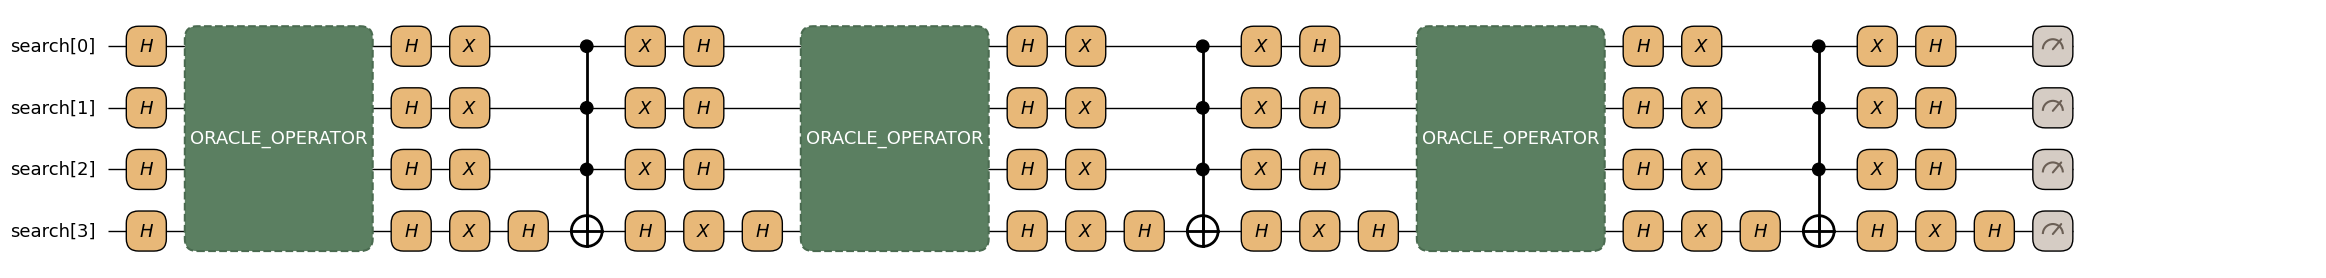

In [5]:
# 振幅増幅前の一様な検索レジスタ分布を測定します。
@qmc.qkernel
def uniform_superposition() -> qmc.Vector[qmc.Bit]:
    search = qmc.qubit_array(SEARCH_QUBITS, name="search")
    _oracle_aux = qmc.qubit(name="oracle_aux")
    search = qmc.h(search)
    return qmc.measure(search)


# 事前計算した反復回数に基づいて、Grover反復を繰り返します。
@qmc.qkernel
def grover_search_example(
    iterations: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    search = qmc.qubit_array(SEARCH_QUBITS, name="search")
    search = qmc.grover_search(search, oracle_operator, iterations)
    return qmc.measure(search)


grover_search_example.draw(iterations=ITERATIONS, fold_loops=False)

In [6]:
# 検索レジスタとオラクル補助量子ビットの合計が5量子ビットであることを確認します。
search_resources = grover_search_example.estimate_resources(
    inputs={"iterations": ITERATIONS}
).simplify()
print("total circuit qubits:", search_resources.qubits)
assert search_resources.qubits == SEARCH_QUBITS + 1

total circuit qubits: 5


## 実行結果

2つの量子カーネルをQiskitへトランスパイルし、同じショット数でサンプリングします。1つ目のヒストグラムはほぼ一様になるはずです。2つ目のヒストグラムでは、3回のGrover反復後に`|0101>`の確率が最も高くなるはずです。

### 量子回路の実行

In [7]:
# 結果を再現できるようにシミュレータのseedを固定し、量子カーネルをトランスパイルしてサンプリングします。
def sample_kernel(kernel, *, bindings: dict[str, int] | None = None, seed: int):
    executable = transpiler.transpile(kernel, bindings=bindings or {})
    executor = transpiler.executor(
        backend=AerSimulator(
            seed_simulator=seed,
            max_parallel_threads=1,
        )
    )
    return executable.sample(executor, shots=SHOTS).result()


before_result = sample_kernel(uniform_superposition, seed=SAMPLER_SEED)
after_result = sample_kernel(
    grover_search_example,
    bindings={"iterations": ITERATIONS},
    seed=SAMPLER_SEED + 1,
)

### 結果のプロットと確認

2つのサンプリング結果を検索レジスタの確率へ変換し、振幅増幅の前後の分布を比較します。

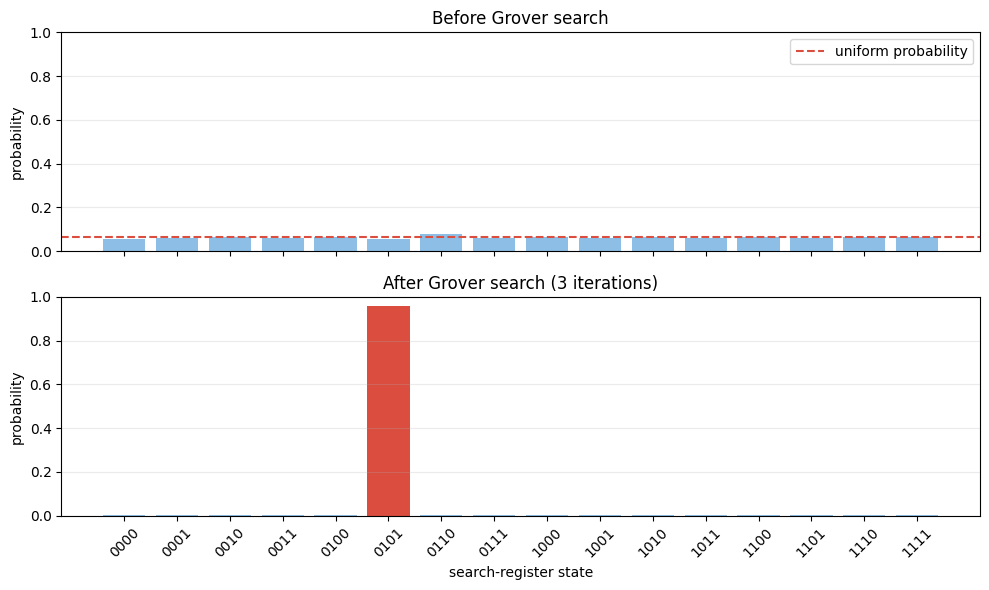

sampled marked-state probability: 0.959961
ideal marked-state probability: 0.961319


In [8]:
# 測定回数を検索レジスタ順のラベルが付いた確率へ変換します。
def state_probabilities(sample_result) -> dict[str, float]:
    return {
        "".join(str(bit) for bit in state): count / sample_result.shots
        for state, count in sample_result.results
    }


before_probabilities = state_probabilities(before_result)
after_probabilities = state_probabilities(after_result)

basis_states = [
    format(index, f"0{SEARCH_QUBITS}b") for index in range(2**SEARCH_QUBITS)
]
before_values = [before_probabilities.get(state, 0.0) for state in basis_states]
after_values = [after_probabilities.get(state, 0.0) for state in basis_states]

# Grover探索の前後で検索レジスタの確率を比較します。
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
axes[0].bar(basis_states, before_values, color="#8DBFE6")
axes[0].axhline(
    1 / 2**SEARCH_QUBITS,
    color="#DB4D3F",
    linestyle="--",
    label="uniform probability",
)
axes[0].set_title("Before Grover search")
axes[0].set_ylabel("probability")
axes[0].legend()

bar_colors = ["#DB4D3F" if state == MARKED_STATE else "#8DBFE6" for state in basis_states]
axes[1].bar(basis_states, after_values, color=bar_colors)
axes[1].set_title(f"After Grover search ({ITERATIONS} iterations)")
axes[1].set_xlabel("search-register state")
axes[1].set_ylabel("probability")
axes[1].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# 一様な入力と、増幅されたマーク状態を検証します。
uniform_probability = 1 / 2**SEARCH_QUBITS
assert all(abs(value - uniform_probability) < 0.06 for value in before_values)
assert max(after_probabilities, key=after_probabilities.get) == MARKED_STATE
assert after_probabilities[MARKED_STATE] > 0.85

print("sampled marked-state probability:", f"{after_probabilities[MARKED_STATE]:.6f}")
print("ideal marked-state probability:", f"{ideal_marked_probability:.6f}")

1つ目のヒストグラムでは、各状態の確率が一様分布の$1/16$に近くなっています。オラクルと拡散演算子を3回繰り返すと、ほぼすべての確率が`|0101>`に集中し、$\sin^2((2r+1)\theta)$から予測される理想値に近づきます。サンプリングによって、厳密な確率から小さなずれが生じます。

どちらのヒストグラムにも補助量子ビットは含めていません。補助量子ビットはオラクルを適用する前後で$|0\rangle$となり、位相キックバックによって4量子ビットの検索レジスタへオラクルの負符号を付けるためだけに使われます。

## リソース推定

Grover反復では、位相オラクルを1回呼び出します。したがって、位相オラクルへの問い合わせ回数は`grover_iteration_count`が返す反復回数と一致します。ここでは、問題サイズとGrover探索における位相オラクルの問い合わせ回数の関係を見てましょう。

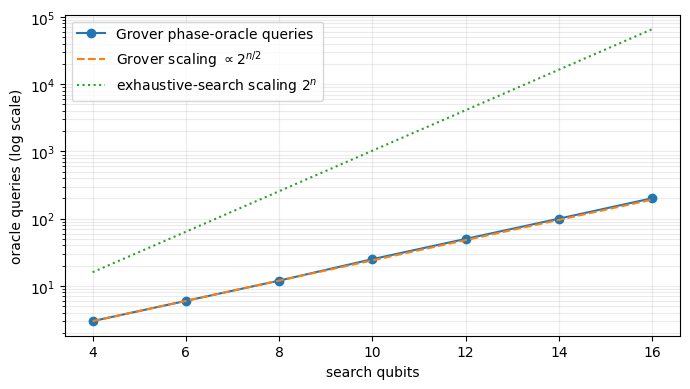

In [9]:
# 検索レジスタの量子ビット数ごとに、位相オラクルへの問い合わせ回数を計算します。
RESOURCE_SEARCH_QUBITS = [4, 6, 8, 10, 12, 14, 16]
grover_query_counts = [
    qmc.grover_iteration_count(num_search_qubits, 1)
    for num_search_qubits in RESOURCE_SEARCH_QUBITS
]

grover_scaling_reference = [
    grover_query_counts[0]
    * 2 ** ((num_search_qubits - RESOURCE_SEARCH_QUBITS[0]) // 2)
    for num_search_qubits in RESOURCE_SEARCH_QUBITS
]
exhaustive_search_reference = [
    2**num_search_qubits for num_search_qubits in RESOURCE_SEARCH_QUBITS
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    RESOURCE_SEARCH_QUBITS,
    grover_query_counts,
    marker="o",
    label="Grover phase-oracle queries",
)
ax.plot(
    RESOURCE_SEARCH_QUBITS,
    grover_scaling_reference,
    linestyle="--",
    label=r"Grover scaling $\propto 2^{n/2}$",
)
ax.plot(
    RESOURCE_SEARCH_QUBITS,
    exhaustive_search_reference,
    linestyle=":",
    label=r"exhaustive-search scaling $2^n$",
)
ax.set_xlabel("search qubits")
ax.set_ylabel("oracle queries (log scale)")
ax.set_xticks(RESOURCE_SEARCH_QUBITS)
ax.set_yscale("log", base=10)
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.tight_layout()
plt.show()

assert grover_query_counts == [3, 6, 12, 25, 50, 100, 201]
assert all(
    later > earlier
    for earlier, later in zip(grover_query_counts, grover_query_counts[1:])
)
assert all(
    grover_queries < exhaustive_queries
    for grover_queries, exhaustive_queries in zip(
        grover_query_counts, exhaustive_search_reference
    )
)

マークされた状態が1つの場合、`grover_iteration_count(n, 1)`によって選ばれる回数は、

$$
r(n)=\left\lfloor\frac{\pi}{4}\sqrt{2^n}\right\rfloor
=\Theta(2^{n/2})
$$

です。マークされた状態が1つの場合、$\theta=\arcsin(1/\sqrt{2^n})\approx1/\sqrt{2^n}$です。主要項の係数$\pi/4$は、最適な角度$\pi/2$を、Grover反復1回あたりの回転角$2\theta$で割ることから得られます。対数プロットでは、Grover探索の$\Theta(2^{n/2})$回の問い合わせと、古典的な全探索の$\Theta(2^n)$回の問い合わせを比較します。したがって、この比較はオラクル問い合わせ計算量について、古典的な全探索に対する2次加速を示しています。

:::{note}
この比較では、位相オラクルを1回適用することを1回の問い合わせとして数え、オラクルの内部回路は考慮していません。具体的な位相オラクルでは、1回の適用に複数のゲートや補助量子ビットが必要になることがあります。そのため、Grover探索では、問題に応じたオラクルの設計が重要となります。
:::

## まとめ

このノートブックでは、Qamomileの`qmc.grover_search`を使ってGrover探索を実装し、16要素の探索空間からマークされた状態を1つ探索しました。

- Grover探索は、位相オラクルと拡散演算子によって、マークされた状態の確率振幅を増幅することで、目標の状態を探索する量子アルゴリズムです。
- `qmc.grover_iteration_count()`は、マークされた状態が1つある場合の最適なGrover反復回数を計算することができます。
- `qmc.grover_search`は一様重ね合わせを準備し、各反復で位相オラクルに続いて拡散演算子を適用します。
- オラクルは問題に依存します。異なる述語やビット列をマークする場合は、それに対応する位相オラクルの実装が必要です。